___

# <font color= #99C8F5> **Perceptual Autoencoder for CIFAR-10 Generation** </font>
#### <font color= #2E9AFE> `Deep Learning`</font>
<Strong> Sofía Maldonado, Óscar Josué Rocha & Viviana Toledo </Strong>

_17/02/2026._

___

# <font color= #99C8F5> **Introduction** </font>

Autoencoders are a type of neural network made up of two parts: first, an **encoder** that encodes input data down to a compressed, lower-dimention representation (***latent space***). Then, a **decoder** reconstructs the input back to its original form, in the best way it can. 

This arquitecture makes autoencoders very useful for image generation purposes: if an encoder can learn to represent a type of data (text, images, or anything else) in a small space, that space can be used to generate new samples based on that information, mimiquing what the training data contained. 

In this exercise, we are using the CIFAR-10 dataset [1] to train a full autoencoder network that can generate images in the dataset's 10 classes. These classes are:
- Airplanes
- Cars
- Birds
- Cats
- Deer
- Dogs
- Frogs
- Horses
- Ships
- Trucks

---

In [1]:
# General
import numpy as np
import pandas as pd
from keras.datasets import cifar10
import os

# Visualization
import matplotlib.pyplot as plt

# Models
import tensorflow as tf
from tensorflow.python.client import device_lib
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout
from keras.optimizers import Adam
from keras import Model

# Loss Function
from tensorflow.keras.applications import VGG19
from tensorflow.keras import Model, Input

2026-02-17 11:28:47.064795: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print(device_lib.list_local_devices())
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 5134022930218082231
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 4344971264
locality {
  bus_id: 1
  links {
  }
}
incarnation: 18319830720002615728
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]
2.20.0
Num GPUs Available:  1


I0000 00:00:1771349329.493011   12914 gpu_device.cc:2020] Created device /device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# <font color= #99C8F5> **Data Loading & Visualization** </font>

In [3]:
# Load Data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

/home/vivienne/anaconda3/envs/deep-learning/lib/python3.11/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


((50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), (10000, 1))

The CIFAR-10 dataset contains 50K training images and 10K testing images. These images have a size of 32x32 pixels with an RGB channel.

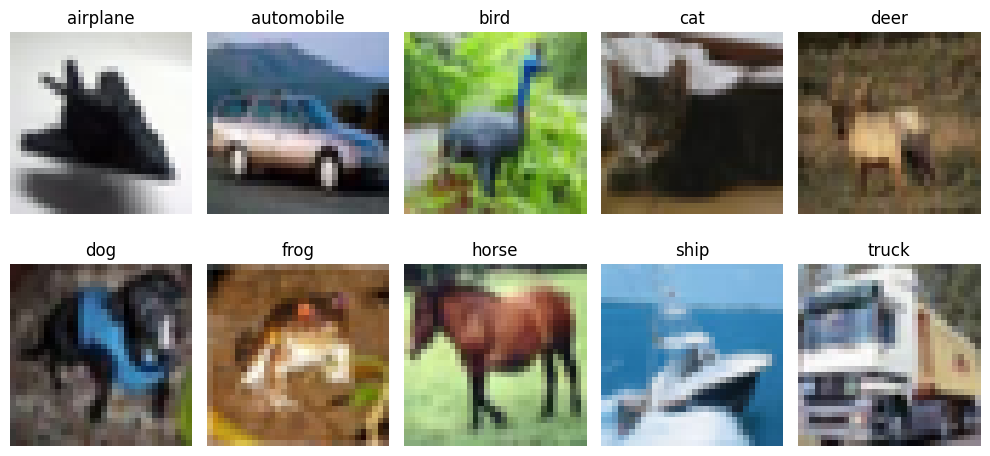

In [4]:
# Flatten labels for visualization
y_train = y_train.flatten()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Create the plot
plt.figure(figsize=(10, 5))
# Select an image for each class
for class_id in range(10):
    index = np.where(y_train == class_id)[0][0]
    # Plot the imaage
    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.tight_layout()
plt.show()

The images have a low resolution, which makes them highly pixelated. This should be taken into account when evaluating the results of the autoencoder.

# <font color= #99C8F5> **Preprocessing** </font>

The objective of this activity is to build an autoencoder capable of recreating images of the CIFAR-10 dataset. For this reason, data-augmentation techniques would be ill-advised, since the learning and comparison between images would be hindered. Thus, only a normalization will be applied.

In [5]:
# Normalization
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

In [6]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [7]:
X_train.min(), X_train.max()

(np.float32(0.0), np.float32(1.0))

# <font color= #99C8F5> **Modeling** </font>

The model architecture will mimic a Convolutional Autoencoder with three levels of compression:

$$
1024_{input}  \rightarrow 256_{h_1} \rightarrow 128_{h_2} \rightarrow 64_{h_3} \rightarrow 32_z \leftarrow 64_{h_3} \leftarrow 128_{h_2} \leftarrow 256_{h_1} \leftarrow 1024_{output}
$$

Building upon the previous experiments with different loss functions and architectures, a **Perceptual Autoencoder was proposed to deal with blurriness**. A Perceptual Autoencoder compares feature similarity instead of only pixel similarity, which means the forms are compared and optimized between images [4] [5] [6] (check references below). 

This way, the loss function becomes a Convolutional Autoencoder trained for image detection, which optimizes similarity between the input and output.

## <font color= #70A9E0> &ensp; • **Perceptual Loss with VGG Model** </font>

The final convolutional layer from the VGG19 model is going to be extracted to use as a loss function. This layer contains deep patterns captured during training. The weights of the model will be freezed so that no more training is performed, and the layer is only used to compare the input images versus the generated ones.

In [8]:
def get_vgg_model():
    # Get VGG model trained with imagenet, with no fixed input shape
    vgg = VGG19(weights='imagenet', include_top=False, input_shape=(None, None, 3))
    vgg.trainable = False           # Freeze weights
    loss_model = Model(inputs=vgg.input, outputs=vgg.get_layer('block5_conv4').output)
    loss_model.trainable = False
    return loss_model

vgg_model = get_vgg_model()

I0000 00:00:1771349331.192822   12914 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


With the previously extracted layer, a customized loss function is defined by calculating the difference between predicted and true images:

In [9]:
def perceptual_loss(y_true, y_pred):
    y_true_features = vgg_model(y_true)
    y_pred_features = vgg_model(y_pred)
    return tf.reduce_mean(tf.square(y_true_features - y_pred_features))

## <font color= #70A9E0> &ensp; • **Convolutional Autoencoder** </font>

Finally, a Convolutional Autoencoder is crafted following the proposed architecture at the start of this section, using the **Adam Optimizer** and a **Perceptual Loss Function**, that will run for 5 epochs.

In [10]:
# Parameters
input_shape = (32,32,3) # 1024

# Input 
input_layer = Input(shape=input_shape)

# Encoder
enc_layer_1 = Conv2D(256, kernel_size=3, activation='relu', padding='same')(input_layer)             
enc_max_pool_1 = MaxPooling2D(pool_size=(2,2))(enc_layer_1)

enc_layer_2 = Conv2D(128, kernel_size=3, activation='relu', padding='same')(enc_max_pool_1)             
enc_max_pool_2 = MaxPooling2D(pool_size=(1,2))(enc_layer_2)

enc_layer_3 = Conv2D(64, kernel_size=3, activation='relu', padding='same')(enc_max_pool_2)             
enc_max_pool_3 = MaxPooling2D(pool_size=(2,1))(enc_layer_3)

enc_layer_4 = Conv2D(32, kernel_size=3, activation='relu', padding='same')(enc_max_pool_3)             
enc_max_pool_4 = MaxPooling2D(pool_size=(1,2))(enc_layer_4)

In [11]:
# Decoder
dec_layer_1 = Conv2D(32, kernel_size=3, activation='relu', padding='same')(enc_max_pool_4)
dec_up_sampling_1 = UpSampling2D(size=(1,2))(dec_layer_1)

dec_layer_2 = Conv2D(64, kernel_size=3, activation='relu', padding='same')(dec_up_sampling_1)
dec_up_sampling_2 = UpSampling2D(size=(2,1))(dec_layer_2)

dec_layer_3 = Conv2D(64, kernel_size=3, activation='relu', padding='same')(dec_up_sampling_2)
dec_up_sampling_3 = UpSampling2D(size=(1,2))(dec_layer_3)

dec_layer_4 = Conv2D(256, kernel_size=3, activation='relu', padding='same')(dec_up_sampling_3)
dec_up_sampling_4 = UpSampling2D(size=(2,2))(dec_layer_4)

# Concatenate
dec_up_sampling_4 = Concatenate()([dec_up_sampling_4, enc_layer_1])
concat = Dropout(0.3)(dec_up_sampling_4)

decoded = Conv2D(3, kernel_size=3, activation='sigmoid', padding='same')(concat)

In [12]:
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss=perceptual_loss)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      7,168 │ input_layer_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │    295,040 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 8,     │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 8, 64) │     73,792 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 32)  │     18,464 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 4, 32)  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 4, 32)  │      9,248 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 32)  │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 8, 8, 64)  │     18,496 │ up_sampling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 8, 64) │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 8, 64) │     36,928 │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,712 │ up_sampling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 512)              │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 620,675 (2.37 MB)

 Trainable params: 620,675 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder.fit(X_train, X_train, batch_size=128, epochs=5, validation_data=(X_test, X_test))

Epoch 1/5


2026-02-17 11:28:56.051027: I external/local_xla/xla/service/service.cc:163] XLA service 0x7aecd80026b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-17 11:28:56.051049: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-17 11:28:56.109487: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-17 11:28:56.707414: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


  1/391 ━━━━━━━━━━━━━━━━━━━━ 1:52:27 17s/step - loss: 0.1129

I0000 00:00:1771349351.152500   12991 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 151ms/step - loss: 0.0237 - val_loss: 0.0086
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - loss: 0.0019 - val_loss: 0.0010
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 111ms/step - loss: 9.5599e-04 - val_loss: 4.7422e-04
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 6.1874e-04 - val_loss: 3.2388e-04


In [15]:
preds = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


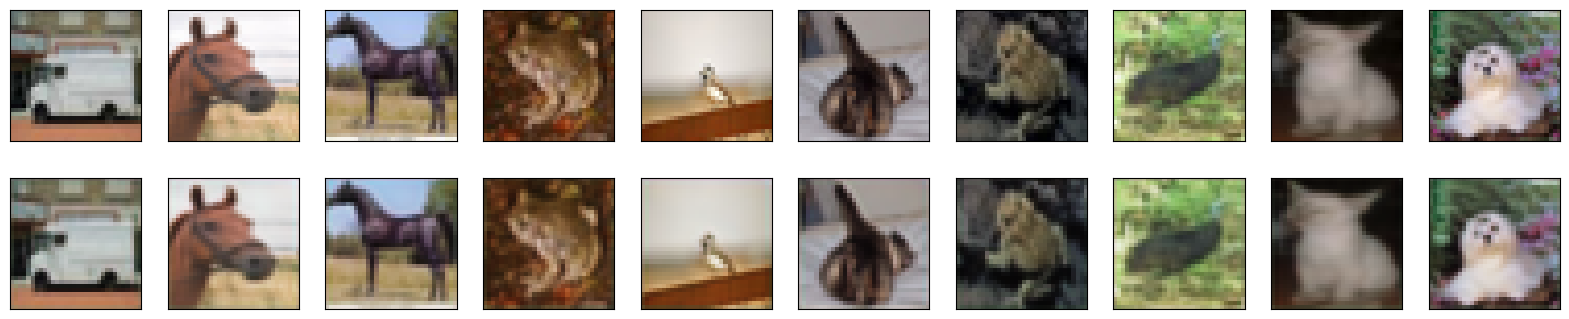

In [16]:
def display(array1, array2):
    """Displays ten random images from each array."""
    n = 10
    indices = np.random.randint(len(array1), size=n)
    images1 = array1[indices, :]
    images2 = array2[indices, :]

    plt.figure(figsize=(20, 4))
    for i, (image1, image2) in enumerate(zip(images1, images2)):
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(image1.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(image2.reshape(32, 32, 3))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

display(X_test, preds)

As shown above, the images are an almost exact replica of the original ones. Additionally, the loss during the training was zero, which pinpoints a perfect fit.

# <font color= #99C8F5> **Conclusions** </font>

The **Perceptual Autoencoder architecture is ideal for the CIFAR-10 dataset**, to the point of creating exact replicas of the input. However, since the loss function is essentially another model, the **computational complexity skyrockets**. If resources are available, and one wants to generate images closest to the input with no blur, a Perceptual Autoencoder is definitely up for the job. 

Furthermore, a **Denoising Autoencoder** could probably have been another option to tackle the blurriness, since they specialize on removing noise from images. Thus, a two-model option with a Denoising Autoencoder as a blur remover is a viable option. 

# <font color= #99C8F5> **Bibliography and References** </font>

[1] Krizhevsky, A. (2009). _Learning Multiple Layers of Features from Tiny Images_. **University of Toronto**. https://www.cs.toronto.edu/~kriz/learning-features-2009-TR.pdf

[2] Valdarrama, S. (2021) _Convolutional autoencoder for image denoising_. **Keras**. https://keras.io/examples/vision/autoencoder/

[3] Chollet, F. (2016) _Building Autoencoders in Keras_. **The Keras Blog**. https://blog.keras.io/building-autoencoders-in-keras.html 

[4] Breddel, G., Flouris, K., Chaitanya, K. Erdill, E. & Konukoglu, E. (2023) _Explicitly Minimizing the Blur Error of Variational Autoencoders_. https://arxiv.org/pdf/2304.05939

[5] Johnson, J., Alahi, A. Fei-Fei, L. (2016, March 27) _Perceptual Losses for Real-Time Style Transfer and Super-Resolution_. **Stanford University**. https://arxiv.org/pdf/1603.08155

[6] GeeksforGeeks. (2025, July 23). _Perceptual Autoencoder: Enhancing Image Reconstruction with Deep Learning_. https://www.geeksforgeeks.org/deep-learning/perceptual-autoencoder-enhancing-image-reconstruction-with-deep-learning/